In [19]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import os
import ROOT
import glob
from scipy import stats

try:
#     plt.style.use('belle2')
    plt.style.use('belle2_serif')
#     plt.style.use('belle2_modern')
except OSError:
    print("Please install belle2 matplotlib style")   
px = 1/plt.rcParams['figure.dpi']

from main.data_tools.extract_ntuples import get_pd, get_np
from main.draw_tools.decorations import b2helix, watermark
from main.draw_tools.stacking_with_error_bars import MC_stack_plot, MC_stack_plot_density

from main.data_tools.error_bars import make_data_weight
from main.data_tools.query_dataframes import cut_dfs_7types

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
def load_root_files(dir_list, tags, tree, cut, variables, bdt_cut):       
    file_map = {tag: [] for tag in tags}
    for tag in tags:
        for d in dir_list:
            # pattern = os.path.join(d,f"{tree}", "without_delM", "ranked", f"{tag}*ranked.root")
            pattern = os.path.join(d,f"{tree}", "ranked", f"{tag}*ranked.root")
            # print(pattern)
            matched_files = glob.glob(pattern)
            matched_files.sort()
            file_map[tag].extend(matched_files)
    for tag in tags:
        print(f"{tag}: {len(file_map[tag])} files found")
    
    dataframes = {}
    for tag in tags:
        dfs = [get_pd(file=fp, tree=tree, base_filter=cut, variables=variables + ["Dstarp_isSignal"]) for fp in file_map[tag]]
        df = pd.concat(dfs, ignore_index=True)
        df["ds_weight"] = 1  # Scale weights
        # df["ds_weight"] = 1/4
        
        # ccbar 분리
        if tag == "ccbar":
            df_signal = df.query("Dstarp_isSignal == 1").copy()
            df_bkg = df.query("Dstarp_isSignal != 1").copy() 

            dataframes["ccbar_sig"] = df_signal.query(cut)
            dataframes["ccbar_bkg"] = df_bkg.query(cut)
        else:
            df.drop(columns="Dstarp_isSignal", inplace=True)
            dataframes[tag] = df.query(cut)

    return dataframes

In [21]:
def plot_stack_with_data(dataframes, tag_order, labels, data_df, var, bins, xlabel, output):
    data_list = [dataframes[tag][var] for tag in tag_order]
    scale_list = [dataframes[tag]["ds_weight"] for tag in tag_order]
    colors = b2helix(len(data_list))

    xbins = np.linspace(*bins, 101)
    bin_centers = (xbins[1:] + xbins[:-1]) / 2
    bin_width = xbins[1] - xbins[0]

    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Stack plot (✔ label 순서 그대로)
    ax.hist(data_list, bins=xbins, weights=scale_list, stacked=True, label=labels,
            histtype='stepfilled', color=colors, edgecolor='black')
    
    # MC stat. error
    flat_data = np.concatenate([np.asarray(d) for d in data_list])
    flat_weights = np.concatenate([np.asarray(w) for w in scale_list])
    sum_w = stats.binned_statistic(flat_data, flat_weights, bins=xbins, statistic="sum")[0]
    sum_w2 = stats.binned_statistic(flat_data, flat_weights**2, bins=xbins, statistic="sum")[0]
    ax.bar(bin_centers, 2*np.sqrt(sum_w2), width=bin_width, bottom=sum_w - np.sqrt(sum_w2),
           color='black', hatch='////', fill=False, lw=0, label="MC stat. unc.")

    # Data points
    # data_hist, _ = np.histogram(data_df[var], bins=xbins)
    # ax.errorbar(bin_centers, data_hist, yerr=np.sqrt(data_hist), fmt='ko', markersize=4, label="Data")
    
    ax.set_xlim(*bins)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(fr"Entries / ({bin_width:.4f} $\mathrm{{GeV/c^2}}$)")
    # ax.legend(loc="upper left", ncol=2, prop={'size':13})
    ax.legend(loc="best", ncol=2, prop={'size':13})

    plt.tight_layout()
    plt.savefig(output)
    plt.show()

In [22]:
tag_order = ['taupair', 'mixed', 'charged', 'ssbar', 'ddbar', 'uubar', 'ccbar_bkg', 'ccbar_sig']
labels = [
    r'$\tau^+\tau^-$', r'$B^0\bar{B}^0$', r'$B^+B^-$',
    r'$s\bar{s}$', r'$d\bar{d}$', r'$u\bar{u}$',
    r'other $c\bar{c}$',  r'Signal'
]

In [23]:

# ================== MAIN SCRIPT ===================

plot_dir = "/media/jykim/T7/saved_plots/DRAW/etaeta/MC16rd_generic/pipi_tag"
os.makedirs(plot_dir, exist_ok=True)

# Settings
tree = "etaeta_pipi_tag"
cut = "rank_Dstarp_chiProb==1"
variables = ["D0_M", "rank_Dstarp_chiProb", "Dstarp_delM"]
bdt_cut="0.86"

# output = "test.png"

# MC 설정
tags = ['ccbar', 'uubar', 'ddbar', 'ssbar', 'charged', 'mixed', 'taupair']
# tag_order = ['taupair', 'mixed', 'charged', 'ssbar', 'ddbar', 'uubar', 'ccbar']
# labels = [r'$\tau^+\tau^-$', r'$B^0\bar{B}^0$', r'$B^+B^-$', r'$s\bar{s}$', r'$d\bar{d}$', r'$u\bar{u}$', r'$c\bar{c}$']

mc_base= "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC16rd/eteeta/MC16rd_etaeta_cuts_v2_260513"
mc_dirs = [
    f"{mc_base}/16rd_2eta_R2_4S_v1",
    f"{mc_base}/16rd_2eta_R2_off_v1",
]
mc_data = load_root_files(mc_dirs, tags, tree, cut, variables, bdt_cut)


ccbar: 2 files found
uubar: 2 files found
ddbar: 2 files found
ssbar: 2 files found
charged: 1 files found
mixed: 1 files found
taupair: 2 files found


/media/jykim/T7/saved_plots/DRAW/etaeta/MC16rd_generic/pipi_tag/MC16rd_etaeta_pipi_tag_stack_v2_with_delM.png


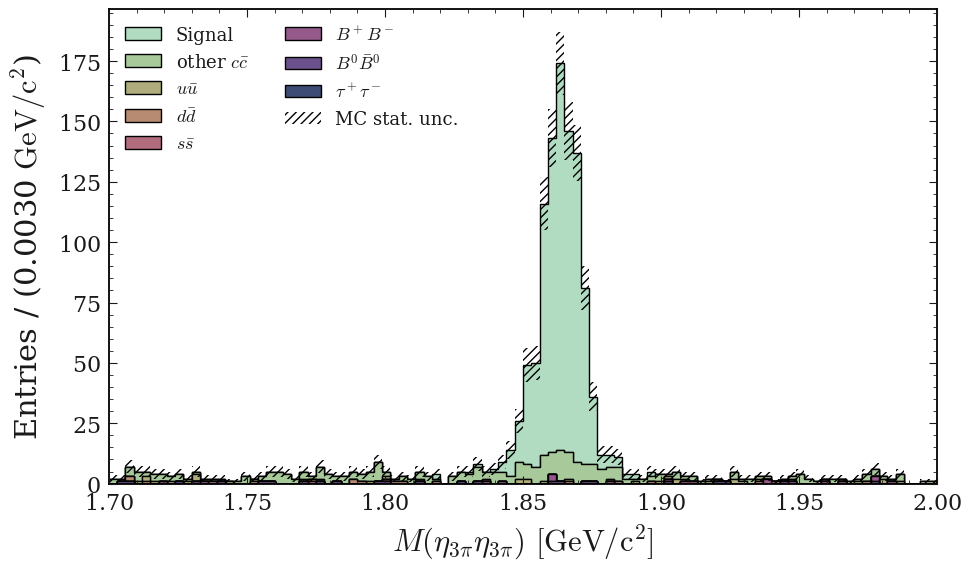

In [24]:
var = "D0_M"
bins = (1.7,2.0)
xlabel = r"$M(\eta_{3\pi}\eta_{3\pi})$ $[\mathrm{{GeV/c^2}}]$"
output = os.path.join(plot_dir, "MC16rd_etaeta_pipi_tag_stack_v2_with_delM.png")
print(output)
plot_stack_with_data(mc_data, tag_order, labels, None, var, bins, xlabel, output)


/media/jykim/T7/saved_plots/DRAW/etaeta/MC16rd_generic/pipi_tag/MC16rd_etaeta_pipi_tag_stack_v2_Dstarp_delM.png


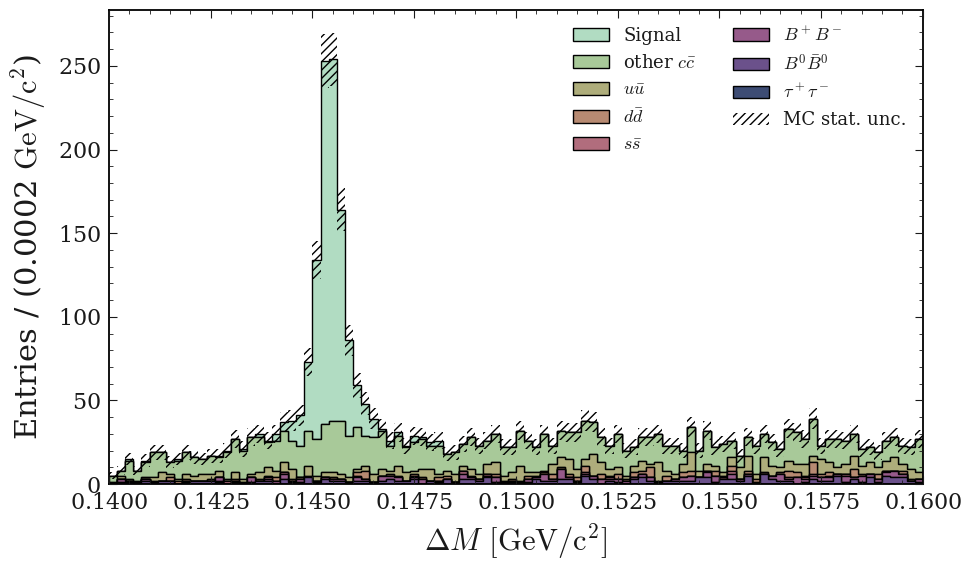

In [18]:
var = "Dstarp_delM"
bins = (0.140, 0.160)

xlabel = r"$\Delta M$ $[\mathrm{{GeV/c^2}}]$"
output = os.path.join(plot_dir, "MC16rd_etaeta_pipi_tag_stack_v2_Dstarp_delM.png")
print(output)

plot_stack_with_data(mc_data, tag_order, labels, None, var, bins, xlabel, output)